In [37]:
# Carga
import pandas as pd
import numpy as np
from sympy import centroid

base_path = "./data/MNIST/"
train = pd.read_csv(base_path + 'fashion-mnist_train.csv')
test = pd.read_csv(base_path + 'fashion-mnist_test.csv')

X_train = train.drop('label', axis=1).to_numpy()
y_train = train['label'].to_numpy()
X_test = test.drop('label', axis=1).to_numpy()
y_test = test['label'].to_numpy()

In [38]:
# Mostrar un par
from matplotlib import pyplot as plt
from ipywidgets import interact, IntSlider

interact(
    lambda i: plt.imshow(X_train[i].reshape(28,28), cmap="gray"), i=IntSlider(min=0, max=len(y_train)-1)
)

interactive(children=(IntSlider(value=0, description='i', max=59999), Output()), _dom_classes=('widget-interac…

<function __main__.<lambda>(i)>

In [79]:
from sklearn.utils import shuffle
# Normalizar
def normalize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std[std == 0] = 1
    return (X - mean) / std

X_train = normalize(X_train)
X_test = normalize(X_test)
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

In [80]:
# K-cluster
K = 9
MAX_ITER = 1000

centroids = X_train[:K]
for _ in range(MAX_ITER):
    print(f"Iter number {_}")
    reiterate = False
    cluster_distances = [X_train - centroid.flatten() for centroid in centroids]
    cluster_norm = np.stack([np.linalg.norm(x, axis=1) for x in cluster_distances])
    min_indexes = np.argmin(cluster_norm, axis=0)
    for i in range(K):
        to_mean_indexes = np.where(min_indexes == i)
        new_centroid = np.mean(X_train[to_mean_indexes], axis=0)
        if not np.allclose(centroids[i], new_centroid, atol=1e-7):
            reiterate = True
        centroids[i] = new_centroid
    if not reiterate:
        break

Iter number 0
Iter number 1
Iter number 2
Iter number 3
Iter number 4
Iter number 5
Iter number 6
Iter number 7
Iter number 8
Iter number 9
Iter number 10
Iter number 11
Iter number 12
Iter number 13
Iter number 14
Iter number 15
Iter number 16
Iter number 17
Iter number 18
Iter number 19
Iter number 20
Iter number 21
Iter number 22
Iter number 23
Iter number 24
Iter number 25
Iter number 26
Iter number 27
Iter number 28
Iter number 29
Iter number 30
Iter number 31
Iter number 32
Iter number 33
Iter number 34
Iter number 35
Iter number 36
Iter number 37
Iter number 38
Iter number 39
Iter number 40
Iter number 41
Iter number 42
Iter number 43
Iter number 44
Iter number 45
Iter number 46
Iter number 47
Iter number 48
Iter number 49
Iter number 50
Iter number 51
Iter number 52
Iter number 53


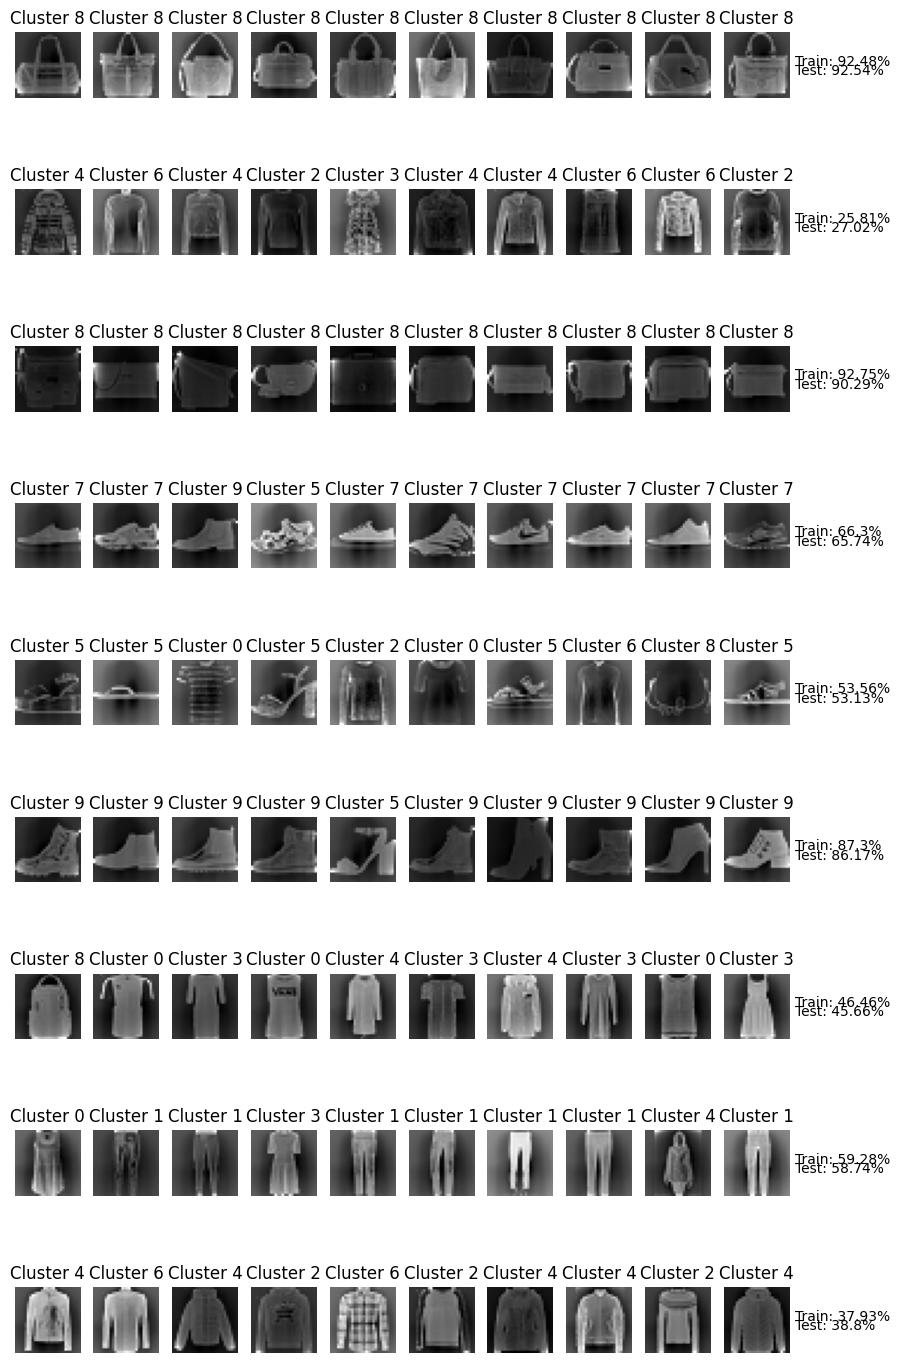

In [82]:
# Visualize the clusters
cluster_distances = [X_test - centroid.flatten() for centroid in centroids]
cluster_norm = np.stack([np.linalg.norm(x, axis=1) for x in cluster_distances])
min_indexes_test = np.argmin(cluster_norm, axis=0)

cluster_distances = [X_train - centroid.flatten() for centroid in centroids]
cluster_norm = np.stack([np.linalg.norm(x, axis=1) for x in cluster_distances])
min_indexes_train = np.argmin(cluster_norm, axis=0)

fig, axes = plt.subplots(nrows=9, ncols=10, figsize=(10, K * 2))
for i in range(K):
    idx = np.where(min_indexes_test == i)[0]
    idx_train = np.where(min_indexes_train == i)[0]

    # Classification purity
    classes_counts = np.bincount(y_test[idx])
    purity_test = np.max(classes_counts) / np.sum(classes_counts)
    # Now for train data
    classes_counts = np.bincount(y_train[idx_train])
    purity_train = np.max(classes_counts) / np.sum(classes_counts)

    for j in range(10):
        axes[i,j].imshow(X_test[idx[j]].reshape(28,28), cmap="gray")
        axes[i, j].axis('off')
        axes[i,j].title.set_text(f"Cluster {y_test[idx[j]]}")

    axes[i,9].text(30, 12, f"Train: {round(purity_train * 100, 2)}%", ha='left', va='center')
    axes[i,9].text(30, 16, f"Test: {round(purity_test * 100, 2)}%", ha='left', va='center')

plt.show()

In [ ]:
""